In [1]:
import os,sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import h5py
sys.path.append('../../code/misc')
#import webplotdigitizer as wpd
from scipy.special import erf

%matplotlib inline
%load_ext autoreload
%autoreload 2
 
from scipy.stats import chi2 as chi2_scipy
from scipy.optimize import dual_annealing
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import rcParams

from scipy.special import factorial

In [2]:
def loadFile(fileString):
    in_file = str(fileString)
    with h5py.File(in_file, 'r') as h5f:
        # Read each dataset back into memory
        counts = h5f['counts'][:]
        det_res = h5f['det_res'][:]
        exp = h5f['exp'][()]
        cin_min = h5f['cin_min'][:]
        cin_max = h5f['cin_max'][:]
        cout_min = h5f['cout_min'][:]
        cout_max = h5f['cout_max'][:]

    E_mean = np.mean([cout_min, cout_max], axis = 0)
    dE = np.diff(E_mean)[0]
    flux = counts/exp/dE
    
    return counts, det_res, exp, cin_min, cin_max, E_mean, dE, flux

In [29]:
## Define the functions we will use
from scipy.special import gammaln

class poisson:
    """ A set offunctions for calculation the chisq associated with different hypotheses
    """
    def __init__(self,ens,dat,null_mod,sig_template,centerE):
        self._ens = ens
        self._dat = dat
        self._null_mod = null_mod
        self._sig_template = sig_template
        self._A_sig = 0.0
        self.centerE = centerE

    #Basic poisson function. Tests the hypothesis.
    def poisson(self,x): 
        null_mod = self._null_mod(self._ens,x[1:],self.centerE) 
        sig_mod = self._sig_template*x[0] 
        
        k = self._dat 
        λ = null_mod + sig_mod 

        if np.any(λ <= 0):
            return np.inf
        
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 
        
        return -2 * np.sum(logPoisson)

    
    #Similar to poisson, but with no sig_mod; this test only evaluates the null case
    def poissonNull(self,x): 
        null_mod = self._null_mod(self._ens,x,self.centerE) 
    
        k = self._dat 
        λ = null_mod 
        
        if np.any(λ <= 0):
            return np.inf
            
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 
        
        return -2 * np.sum(logPoisson)

    
    #Same as poisson, but with adjusted definitions for the null_mod and sig_mod variables
    def poissonFixedSignal(self,x):
        null_mod = self._null_mod(self._ens,x,self.centerE)
        sig_mod = self._sig_template*self._A_sig

        k = self._dat 
        λ = null_mod + sig_mod

        if np.any(λ <= 0):
            return np.inf
        
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 

        return -2 * np.sum(logPoisson)
    
    def fix_signal_strength(self,A_sig):
        self._A_sig = A_sig
        
def old_mod_poly(ens,x):
    """ A simple polynomial model for the background
    """
    A, B, C = x
    return A+B*ens + C*ens**2

def mod_poly(ens,x,eVal):
    """ A simple polynomial model for the background
    """
    A, B, C = x
    return A + B*(ens - eVal) + C*(ens - eVal)**2

def mod_power_law(ens, x):
    A, B = x
    return A*(ens)**B

In [30]:
def return_sin_theta_lim(E_line,flux,D_factor):
    """
    D_factor [keV/cm^2]
    flux [cts/cm^2/s/sr]
    E_line [keV] (dark matter mass is twice this value)
    returns: associated sin^2(2theta)
    """
    DMmass = 2.*E_line
    res = (4.*np.pi*DMmass/D_factor)/1.361e-22*(1/DMmass)**5*flux
    return res

def quadratic(E, a, b, c):
    return a*E**2 + b*E + c
    
def Gaussian_Line(E_min, E_max, E_cent, Amp, std):
    return Amp*(erf((E_cent - E_min)/(np.sqrt(2)*std)) - erf((E_cent - E_max)/(np.sqrt(2)*std)))/2.

def powerLaw(E, a, b):
    return a*(E**b)

In [31]:
def runPipeline(counts, det_res, exp, cin_min, cin_max, E_mean, dE, lineVal, window):
    
    Input_Bkg = quadratic(E_mean, 0, 0, 0.004) # cts/cm^2/s/keV
    Input_Sig = Gaussian_Line(cin_min, cin_max, lineVal, 0.5, 0.005)
    Input_Model = Input_Bkg + Input_Sig

    Output_Model = np.matmul(det_res, Input_Model)

    whs_reduced = np.where((E_mean >= lineVal-window) & (E_mean <= lineVal+window))[0]
    E_mean_reduced = E_mean[whs_reduced]
    counts_reduced = counts[whs_reduced]
    Output_Model_reduced = Output_Model[whs_reduced]

    #Best fit with just background
    poisson_instance = poisson(E_mean_reduced,counts_reduced,mod_poly,(Output_Model_reduced * (exp * dE)),lineVal)
    mn_null = minimize(poisson_instance.poissonNull,np.array([0.3,-0.1,0.01])*(exp * dE),method='Nelder-Mead')

    backgroundParams = mn_null.x

    #Best fit with signal and background
    mn = minimize(poisson_instance.poisson,np.array([(1.e-2) * (exp * dE),mn_null.x[0],mn_null.x[1],mn_null.x[2]]),method='Nelder-Mead')
    signalParams = mn.x

    #Alright, now for the meat of it. We need to compute the profile likelihood
    A_sig_array = np.linspace(-20,20,100)

    bfList = []

    poisson_sig_array = np.zeros(len(A_sig_array))
    bf = mn.x[1:]
    
    #Iterate over every the signal array
    for i in range(len(A_sig_array)):
        poisson_instance.fix_signal_strength(A_sig_array[i])
        mn_profile = minimize(poisson_instance.poissonFixedSignal,bf,method='Nelder-Mead',
                          options={'fatol':1e-10,'xatol':1e-10,'adaptive':True})
        bf = mn_profile.x
        poisson_sig_array[i] = mn_profile.fun
        bfList.append(bf)


    bestFit = np.min(poisson_sig_array)
    testStat = poisson_sig_array-bestFit

    amin = np.argmin((testStat - 2.71)**2) #2.71 comes from Wilk's Theorem, if memory serves
    limit_signal_strength = A_sig_array[amin]

    ReducedVals = [whs_reduced, E_mean_reduced, counts_reduced, Output_Model_reduced]

    
    return backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, ReducedVals

In [32]:
def relevantPlots(E_mean, counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, lineVal):
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))

    whsReduced = reducedVals[0]
    EMeanReduced = reducedVals[1]
    counts_reduced  = reducedVals[2]
    output_reduced = reducedVals[-1]
    
    #Data vs background model
    ax[0,0].plot(EMeanReduced, counts_reduced)
    ax[0,0].plot(EMeanReduced, mod_poly(EMeanReduced, backgroundParams, lineVal))
    ax[0,0].set_title("Data vs. Background Model")
    ax[0,0].set_xlabel("E (keV)")
    ax[0,0].set_ylabel("Counts")

    
    #Data vs signal + background model
    ax[1,0].plot(EMeanReduced, counts_reduced)
    ax[1,0].plot(EMeanReduced, mod_poly(EMeanReduced, backgroundParams, lineVal) + output_reduced)
    ax[1,0].set_title("Data vs. Signal + Background Model")
    ax[1,0].set_xlabel("E (keV)")
    ax[1,0].set_ylabel("Counts")
        
    ax[0,1].plot(A_sig_array,testStat,'k-')
    ax[0,1].axhline(2.71+np.min(testStat),color="red",linestyle="dotted")
    ax[0,1].set_title("Profile Likelihood")
    ax[0,1].set_xlabel(r"$E_{\rm UXL}$ Line Flux [cts/cm$^2$/s/sr]")
    ax[0,1].set_ylabel("Test Statistic")

    #Now we get some specialized graphs. First, the minimum point on the profile likelihood
    targetVal = 2.71+np.min(testStat)
    proximityMatrix = abs(testStat - targetVal)

    closestIndex = np.argmin(proximityMatrix)
    
    ax[0,2].plot(EMeanReduced, counts_reduced)     
    ax[0,2].plot(EMeanReduced, mod_poly(EMeanReduced, bfList[closestIndex], lineVal) + output_reduced)
    ax[0,2].set_title("Data vs. 90% Limit Plot")
    ax[0,2].set_xlabel("E (keV)")
    ax[0,2].set_ylabel("Counts")

    #And, lastly, the Best Fit plot
    targetVal = np.min(testStat)
    proximityMatrix = abs(testStat - targetVal)

    closestIndex = np.argmin(proximityMatrix)
    
    ax[1,2].plot(EMeanReduced, counts_reduced)     
    ax[1,2].plot(EMeanReduced, mod_poly(EMeanReduced, bfList[closestIndex], lineVal) + output_reduced)
    ax[1,2].set_title("Data vs. Best Fit Plot")
    ax[1,2].set_xlabel("E (keV)")
    ax[1,2].set_ylabel("Counts")
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# For a File Beginning In 1

In [ ]:
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux = loadFile('fileStorage1/101001010/outputFile.h5')

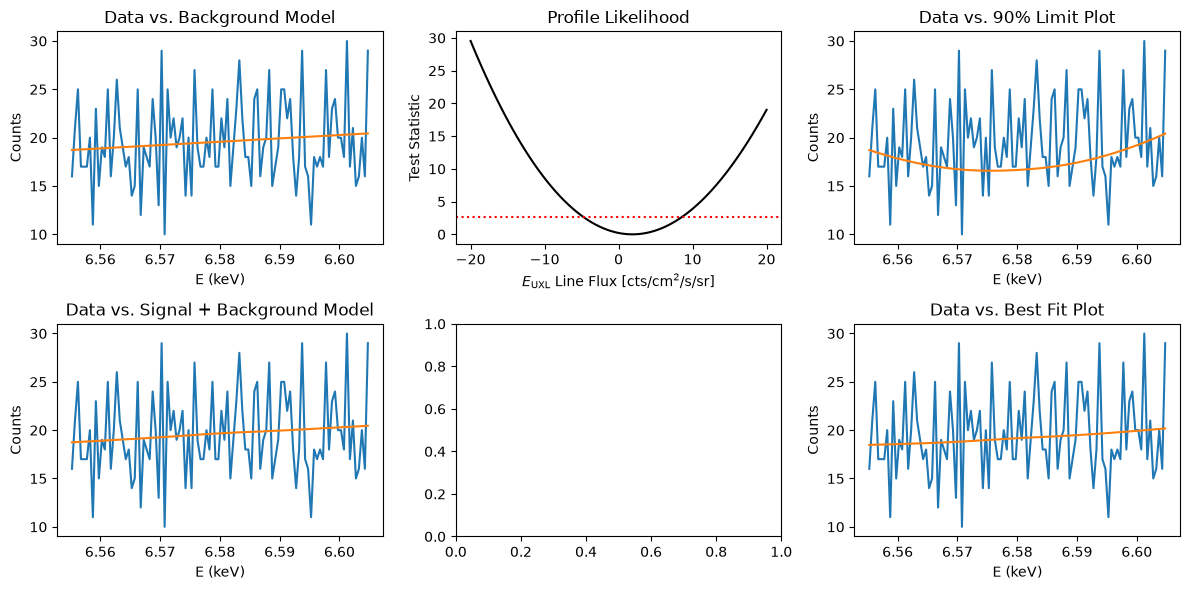

In [35]:
backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.025)
fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.580)

# For a File Beginning In 0

In [ ]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux = loadFile('fileStorage0/000100000/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a file beginning in 2

In [ ]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux = loadFile('fileStorage2/201000010/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a file beginning in 3

In [ ]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux = loadFile('fileStorage3/300000010/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.025)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a file beginning in 9

In [ ]:
# Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux = loadFile('fileStorage9/900002010/outputFile.h5')
# backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.580, 0.25)
# fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.58)

# For a File That Actually Has the Iron Line

In [7]:
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux = loadFile('ironDirectory/300003010/outputFile.h5')

/tmp/ipykernel_202902/1165489971.py:43: RuntimeWarning: invalid value encountered in subtract
  testStat = poisson_sig_array-bestFit


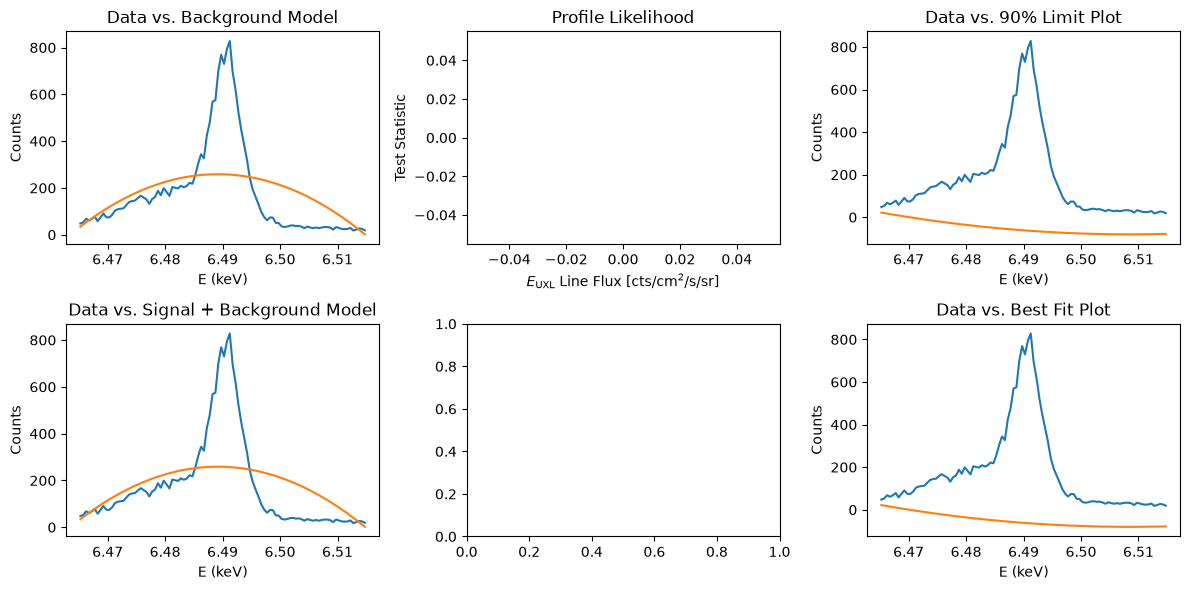

In [40]:
backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.49, 0.025)
fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.49)